# Inspección de un entrenamiento por escena

Este notebook lee los resultados **ya guardados** por `train.py`. No vuelve a entrenar ni renderiza checkpoints. Puede ejecutarse en CPU, sin cargar NeRF ni las dependencias CUDA del renderizador.

Ejecuta las celdas en orden. Selecciona una carpeta de entrenamiento; para revisar otra escena cambia `RUN_DIR` y vuelve a ejecutar desde esa celda. Si los resultados están en otro equipo, ejecuta allí este notebook o copia la carpeta de resultados.

## 1. Localizar y seleccionar el entrenamiento

In [3]:
from pathlib import Path
import ast
import re
import numpy as np
import torch
import matplotlib.pyplot as plt

RESULTS_ROOT = Path("results")  # También puede ser una ruta absoluta.
runs = sorted({p.parent for p in RESULTS_ROOT.rglob("params_full.txt")} |
              {p.parent for p in RESULTS_ROOT.rglob("test_*_conv.pt")})
print("Carpetas de entrenamiento encontradas:")
for path in runs:
    print(" -", path)
if not runs:
    print("No hay resultados locales. Ajusta RESULTS_ROOT o copia los resultados del otro equipo.")

Carpetas de entrenamiento encontradas:
 - results/scene_1_5views_19264


In [4]:
RUN_DIR = RESULTS_ROOT / "scene_1_5views_19264"  # Cambia esta carpeta.
VIEW_ID = 0  # Índice de test, no número de paso ni necesariamente cámara original.

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"No existe {RUN_DIR.resolve()}. Ajusta RUN_DIR al equipo actual.")

params = {}
params_path = RUN_DIR / "params_full.txt"
if params_path.exists():
    for line in params_path.read_text().splitlines():
        key, sep, value = line.partition("=")
        if sep:
            try:
                params[key.strip()] = ast.literal_eval(value.strip())
            except (ValueError, SyntaxError):
                params[key.strip()] = value.strip()
else:
    print("No se encontró params_full.txt; se podrán visualizar los tensores igualmente.")

for key in ("scene", "exp_name", "data_root_fp", "num_views", "n_bins",
            "img_shape_test", "img_scale", "aabb", "exposure_time", "start_opl"):
    if key in params:
        print(f"{key}: {params[key]}")
print("Carpeta:", RUN_DIR.resolve())

exp_name: scene_1_5views_19264
data_root_fp: ./data/scene_1.h5
num_views: 5
n_bins: 1034
img_shape_test: 256
img_scale: 100
aabb: [-1.8, -0.05, -1.8, 1.8, 3.55, 1.8]
exposure_time: 0.009
start_opl: 10.1
Carpeta: /home/crisr_cvail/miTransientNERF---HoCV/results/scene_1_5views_19264


## 2. Qué contiene cada archivo

| Archivo | Significado |
| --- | --- |
| `test_i_conv.pt` | Transitorio predicho desde la vista de prueba `i`: `[alto, ancho, bins, RGB]`. |
| `test_i_depth.pt` | Profundidad predicha desde la misma cámara. |
| `radiance_field_PASO.pth` | Pesos de la red en ese paso de entrenamiento. |
| `occupancy_grid_PASO.pth` | Cuadrícula de ocupación usada para renderizar ese checkpoint. |
| `optimizer_*.pth`, `scheduler_*.pth`, `variables.pth` | Estado para reanudar entrenamiento. |
| `params_full.txt` | Configuración del experimento. |
| `events.out.tfevents.*` | Historial de TensorBoard. |

El consecutivo `i` identifica **cámaras de test**, no iteraciones. Los `.pt` se sobrescriben cada 1000 pasos en el código actual. No contienen un paso asociado: tener un checkpoint 10000 no garantiza que todas las vistas se hayan terminado de actualizar si se interrumpió el resumen.

Para MITransient con 25 cámaras y 2 vistas de entrenamiento, el cargador actual entrena con cámaras 0 y 24; `test_0` a `test_22` corresponden a cámaras 1 a 23. Para otros conjuntos, no asumas esa correspondencia.

In [5]:
def indexed_files(suffix):
    found = {}
    for path in RUN_DIR.glob(f"test_*_{suffix}.pt"):
        match = re.fullmatch(rf"test_(\d+)_{suffix}\.pt", path.name)
        if match:
            found[int(match.group(1))] = path
    return found

conv_files = indexed_files("conv")
depth_files = indexed_files("depth")
view_ids = sorted(conv_files.keys() & depth_files.keys())
print("Vistas con transitorio y profundidad:", view_ids)
print("Sin profundidad:", sorted(conv_files.keys() - depth_files.keys()))
print("Sin transitorio:", sorted(depth_files.keys() - conv_files.keys()))

def checkpoint_steps(prefix):
    return {int(p.stem.rsplit("_", 1)[1]) for p in RUN_DIR.glob(f"{prefix}_*.pth")
            if p.stem.rsplit("_", 1)[1].isdigit()}

steps = sorted(checkpoint_steps("radiance_field") & checkpoint_steps("occupancy_grid"))
print("Pasos con ambos archivos para renderizar:", steps)
if not view_ids:
    raise RuntimeError("No hay pares test_i_conv.pt / test_i_depth.pt en esta carpeta.")

Vistas con transitorio y profundidad: [0]
Sin profundidad: []
Sin transitorio: []
Pasos con ambos archivos para renderizar: []


## 3. Ver una cámara: imagen integrada y profundidad

Sumar el eje temporal produce la imagen integrada. Con `DISPLAY_SCALE = None` se usa `img_scale` del entrenamiento, igual que en TensorBoard. Si falta, se aplica un percentil para la vista seleccionada. Puedes introducir una escala positiva manualmente si la imagen queda oscura o saturada.

La exposición y la corrección gamma son **solo para visualizar**, no una validación cuantitativa. Los ceros de profundidad pueden corresponder a rayos sin contribución; no deben interpretarse automáticamente como una superficie en la cámara. La unidad depende de las coordenadas y la configuración usadas al entrenar.

Solo carga archivos del entrenamiento que conozcas. Cada transitorio puede ocupar cientos de MB; el notebook conserva únicamente el transitorio de la vista seleccionada.

Transitorio: (256, 256, 1034, 3) | profundidad: (256, 256)
Escala visual: 100.0
Valores no finitos: transitorio = 0 ; profundidad = 0


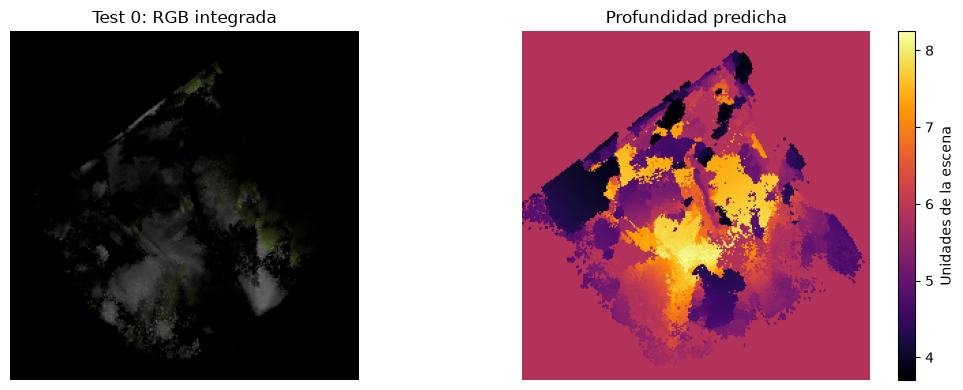

In [6]:
DISPLAY_SCALE = None

def load_view(view_id):
    if view_id not in view_ids:
        raise ValueError(f"Vista {view_id} no disponible. Elige entre {view_ids}.")
    transient = torch.load(conv_files[view_id], map_location="cpu", weights_only=True)
    depth = torch.load(depth_files[view_id], map_location="cpu", weights_only=True)
    if not isinstance(transient, torch.Tensor) or not isinstance(depth, torch.Tensor):
        raise TypeError("Se esperaban tensores guardados por misc/summary.py.")
    if transient.ndim != 4 or transient.shape[-1] != 3:
        raise ValueError(f"Forma de transitorio inesperada: {tuple(transient.shape)}")
    depth = depth.float().reshape(transient.shape[:2]).numpy()
    return transient.float(), depth

transient, depth = load_view(VIEW_ID)
integrated = transient.sum(dim=-2).numpy()
scale = DISPLAY_SCALE if DISPLAY_SCALE is not None else params.get("img_scale")
if scale is None:
    finite = integrated[np.isfinite(integrated)]
    scale = max(float(np.quantile(finite, 0.99)), 1e-8) if finite.size else 1.0
    print("Escala automática de esta vista; no usar para comparar métricas.")
scale = float(scale)
if not np.isfinite(scale) or scale <= 0:
    raise ValueError("DISPLAY_SCALE / img_scale debe ser finito y positivo.")

def preview(image):
    return np.clip(np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0) / scale, 0, 1) ** (1 / 2.2)

print("Transitorio:", tuple(transient.shape), "| profundidad:", depth.shape)
print("Escala visual:", scale)
print("Valores no finitos: transitorio =", int((~torch.isfinite(transient)).sum()),
      "; profundidad =", int((~np.isfinite(depth)).sum()))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(preview(integrated))
axes[0].set_title(f"Test {VIEW_ID}: RGB integrada")
im = axes[1].imshow(np.ma.masked_invalid(depth), cmap="inferno")
axes[1].set_title("Profundidad predicha")
fig.colorbar(im, ax=axes[1], label="Unidades de la escena")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Inspeccionar el transitorio de un píxel

Las curvas muestran intensidad predicha por bin temporal, antes de gamma y exposición visual. Cambia `PIXEL` por `(fila, columna)` para inspeccionar otra superficie. Para validar el tiempo de llegada y la amplitud hay que comparar con la medición de referencia; aquí solo se muestra la predicción.

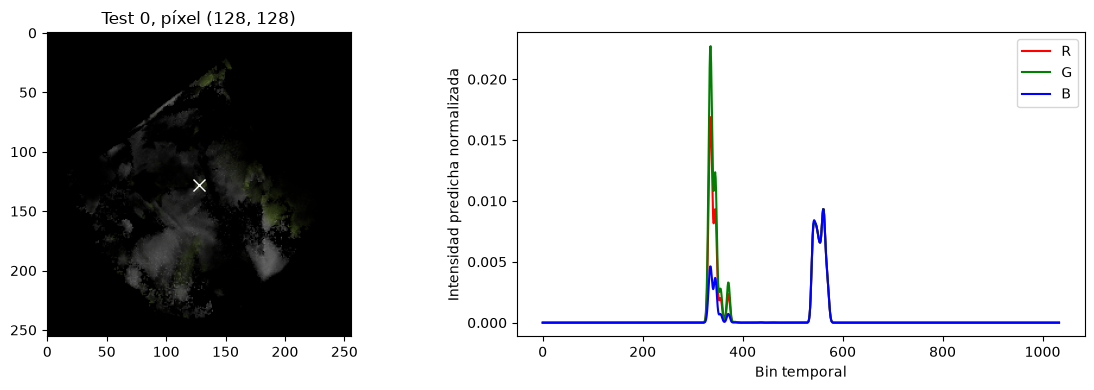

In [7]:
PIXEL = (transient.shape[0] // 2, transient.shape[1] // 2)
row, col = PIXEL
if not (0 <= row < transient.shape[0] and 0 <= col < transient.shape[1]):
    raise ValueError("PIXEL está fuera de la imagen.")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(preview(integrated))
axes[0].plot(col, row, "wx", markersize=9)
axes[0].set_title(f"Test {VIEW_ID}, píxel {PIXEL}")
for channel, color in enumerate(("red", "green", "blue")):
    axes[1].plot(transient[row, col, :, channel].numpy(), color=color, label="RGB"[channel])
axes[1].set(xlabel="Bin temporal", ylabel="Intensidad predicha normalizada")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Galería de vistas de prueba

Carga las vistas una a una y conserva solo sus imágenes integradas. Todas usan la misma escala visual definida arriba. Esta galería muestra la escena desde las cámaras reservadas; no es una malla ni una visualización 3D interactiva.

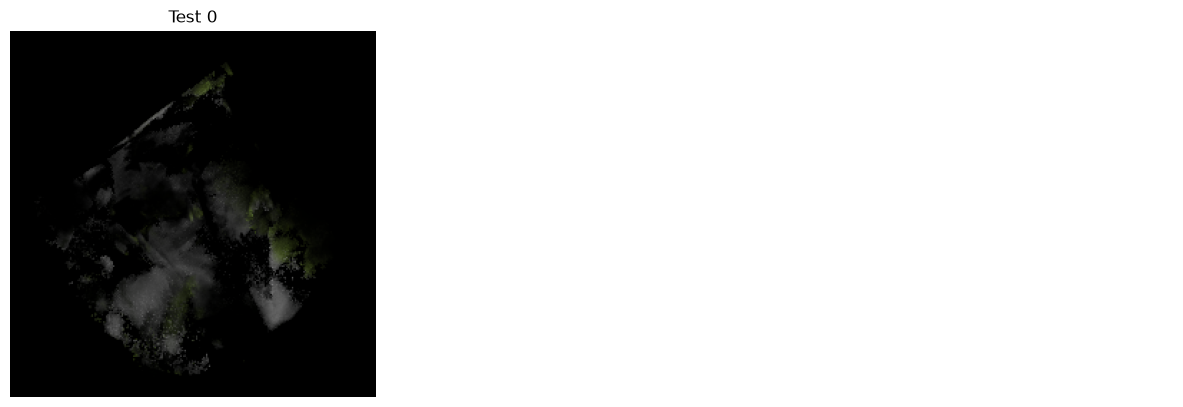

In [8]:
GALLERY_IDS = view_ids[:6]  # Usa view_ids para mostrar todas.
if GALLERY_IDS:
    fig, axes = plt.subplots((len(GALLERY_IDS) + 2) // 3, 3,
                             figsize=(12, 4 * ((len(GALLERY_IDS) + 2) // 3)), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, view_id in zip(axes.flat, GALLERY_IDS):
        tensor, _depth = load_view(view_id)
        ax.imshow(preview(tensor.sum(dim=-2).numpy()))
        ax.set_title(f"Test {view_id}")
        del tensor, _depth
    plt.tight_layout()
    plt.show()

## 6. Validar el entrenamiento con el historial

Ejecuta en una terminal el comando que imprime la siguiente celda y abre `http://localhost:6006`. En un servidor remoto, reenvía el puerto 6006.

- **Scalars → `Loss/train`**: busca descenso y ausencia de NaN; una pérdida baja no demuestra generalización.
- **Images → `rgbdn`**: cada columna es una cámara de test. Las filas son referencia, predicción integrada, profundidad y opacidad. Compara estructura y brillo en varios pasos.
- **Images → `transient_plots`**: compara curvas predichas y reales de los píxeles seleccionados. Revisa posición, amplitud y forma de los picos.

El PSNR de las imágenes se imprime durante el entrenamiento, pero el código actual no lo registra como escalar. Los `.pt` contienen predicciones, no las referencias: por sí solos no permiten calcular PSNR, SSIM ni error de profundidad. Para una evaluación numérica se necesita el dataset original, la correspondencia de cámaras y la misma normalización del cargador.

`eval.py` todavía requiere adaptación para las escenas MITransient: contiene escalas de escenas originales, resolución fija, lectura de JSON y profundidad de referencia obligatoria. Este notebook permite inspeccionar los resultados guardados sin depender de ese script.

In [9]:
import shlex
print(f"tensorboard --logdir {shlex.quote(str(RUN_DIR.resolve()))} --port 6006")
print("Archivos de eventos encontrados:", len(list(RUN_DIR.glob("events.out.tfevents.*"))))

tensorboard --logdir /home/crisr_cvail/miTransientNERF---HoCV/results/scene_1_5views_19264 --port 6006
Archivos de eventos encontrados: 1
